In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import joblib
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

In [2]:
train_data = pd.read_csv('data/processed/train_with_rul.csv')
val_data = pd.read_csv('data/processed/val_with_rul.csv')

print(f"Train shape: {train_data.shape}")
print(f"Val shape: {val_data.shape}")
print(f"\nColumns: {train_data.columns.tolist()}")

Train shape: (16340, 28)
Val shape: (4291, 28)

Columns: ['unit_number', 'time_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'RUL', 'RUL_clipped']


## Finding which sensors are constant

In [3]:
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
sensor_variance = train_data[sensor_cols].var().sort_values()
sensor_variance

sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.560099e-28
sensor_10    1.579840e-25
sensor_5     9.400882e-24
sensor_1     3.967039e-21
sensor_6     1.896621e-06
sensor_15    1.398774e-03
sensor_8     5.029529e-03
sensor_13    5.154739e-03
sensor_21    1.172138e-02
sensor_20    3.250708e-02
sensor_11    7.120309e-02
sensor_2     2.491500e-01
sensor_12    5.412357e-01
sensor_7     7.799662e-01
sensor_17    2.390991e+00
sensor_3     3.734227e+01
sensor_4     8.065170e+01
sensor_14    3.775534e+02
sensor_9     5.061078e+02
dtype: float64

In [4]:
# We can see that senosrs 1 5 10 16 18 19 have value 0 or near to 0
# Drop Constant Sensors

In [5]:
# Identify sensors with near-zero variance (threshold: 0.00000001)
constant_sensors = sensor_variance[sensor_variance < 0.00000001].index.tolist()
constant_sensors



['sensor_19', 'sensor_18', 'sensor_16', 'sensor_10', 'sensor_5', 'sensor_1']

In [6]:
# Drop from both train and val
train_data = train_data.drop(columns=constant_sensors)
val_data = val_data.drop(columns=constant_sensors)


In [7]:
train_data.shape

(16340, 22)

In [8]:
val_data.shape

(4291, 22)

## Operating Settings are also constant, drop them

In [9]:
# In FD001, operating settings are nearly constant — drop them
op_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']

train_data = train_data.drop(columns=op_cols)
val_data = val_data.drop(columns=op_cols)


In [10]:
train_data.shape

(16340, 19)

In [12]:
train_data.columns.tolist()

['unit_number',
 'time_cycles',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_17',
 'sensor_20',
 'sensor_21',
 'RUL',
 'RUL_clipped']

In [13]:
val_data.shape

(4291, 19)

In [14]:
train_data.head()

,unit_number,time_cycles,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL,RUL_clipped
0,1,1,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191,125
1,1,2,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190,125
2,1,3,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189,125
3,1,4,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188,125
4,1,5,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187,125


## Feature Selection Done

**Dropped columns:**
- Sensors with near-zero variance: [list them]
- Operating settings (constant in FD001): op_setting_1, 2, 3

**Why:** Constant features add no predictive signal but increase model complexity. Removing them speeds up training and reduces overfitting risk.

**Remaining:** 15 sensors + cycle/engine IDs + RUL targets.

## Rolling Window Features

In [16]:
# Get sensors that survived after dropping constants
current_sensors = [col for col in train_data.columns if col.startswith('sensor_')]
current_sensors

['sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_17',
 'sensor_20',
 'sensor_21']

In [18]:
def add_rolling_features(df, sensor_cols, windows=[5, 10]):
    
    df = df.copy()
    
    for sensor in sensor_cols:
        for window in windows:
            # Rolling mean per engine
            df[f'{sensor}_roll_mean_{window}'] = (
                df.groupby('unit_number')[sensor]
                  .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
            )
            # Rolling std per engine
            df[f'{sensor}_roll_std_{window}'] = (
                df.groupby('unit_number')[sensor]
                  .transform(lambda x: x.rolling(window=window, min_periods=1).std())
            )
    
    return df



In [19]:
# Applying rolling features

In [21]:
train_data = add_rolling_features(train_data, current_sensors, windows=[5, 10])
val_data = add_rolling_features(val_data, current_sensors, windows=[5, 10])


In [22]:
train_data.shape

(16340, 79)

In [23]:
val_data.shape

(4291, 79)

In [24]:
# Started with 19 columns. Added 4 new columns per sensor (mean_5, std_5, mean_10, std_10) × 15 sensors = 60 new columns. 19 + 60 = 79 columns.

In [25]:
train_data.head()

,unit_number,time_cycles,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL,RUL_clipped,sensor_2_roll_mean_5,sensor_2_roll_std_5,sensor_2_roll_mean_10,sensor_2_roll_std_10,sensor_3_roll_mean_5,sensor_3_roll_std_5,sensor_3_roll_mean_10,sensor_3_roll_std_10,sensor_4_roll_mean_5,sensor_4_roll_std_5,sensor_4_roll_mean_10,sensor_4_roll_std_10,sensor_6_roll_mean_5,sensor_6_roll_std_5,sensor_6_roll_mean_10,sensor_6_roll_std_10,sensor_7_roll_mean_5,sensor_7_roll_std_5,sensor_7_roll_mean_10,sensor_7_roll_std_10,sensor_8_roll_mean_5,sensor_8_roll_std_5,sensor_8_roll_mean_10,sensor_8_roll_std_10,sensor_9_roll_mean_5,sensor_9_roll_std_5,sensor_9_roll_mean_10,sensor_9_roll_std_10,sensor_11_roll_mean_5,sensor_11_roll_std_5,sensor_11_roll_mean_10,sensor_11_roll_std_10,sensor_12_roll_mean_5,sensor_12_roll_std_5,sensor_12_roll_mean_10,sensor_12_roll_std_10,sensor_13_roll_mean_5,sensor_13_roll_std_5,sensor_13_roll_mean_10,sensor_13_roll_std_10,sensor_14_roll_mean_5,sensor_14_roll_std_5,sensor_14_roll_mean_10,sensor_14_roll_std_10,sensor_15_roll_mean_5,sensor_15_roll_std_5,sensor_15_roll_mean_10,sensor_15_roll_std_10,sensor_17_roll_mean_5,sensor_17_roll_std_5,sensor_17_roll_mean_10,sensor_17_roll_std_10,sensor_20_roll_mean_5,sensor_20_roll_std_5,sensor_20_roll_mean_10,sensor_20_roll_std_10,sensor_21_roll_mean_5,sensor_21_roll_std_5,sensor_21_roll_mean_10,sensor_21_roll_std_10
0,1,1,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191,125,641.820000,NaN,641.820000,NaN,1589.700000,NaN,1589.700000,NaN,1400.600000,NaN,1400.600000,NaN,21.61,NaN,21.61,NaN,554.360000,NaN,554.360000,NaN,2388.0600,NaN,2388.0600,NaN,9046.190000,NaN,9046.190000,NaN,47.470,NaN,47.470,NaN,521.660,NaN,521.660,NaN,2388.020,NaN,2388.020,NaN,8138.620000,NaN,8138.620000,NaN,8.419500,NaN,8.419500,NaN,392.000000,NaN,392.000000,NaN,39.060000,NaN,39.060000,NaN,23.419000,NaN,23.419000,NaN
1,1,2,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190,125,641.985000,0.233345,641.985000,0.233345,1590.760000,1.499066,1590.760000,1.499066,1401.870000,1.796051,1401.870000,1.796051,21.61,0.0,21.61,0.0,554.055000,0.431335,554.055000,0.431335,2388.0500,0.014142,2388.0500,0.014142,9045.130000,1.499066,9045.130000,1.499066,47.480,0.014142,47.480,0.014142,521.970,0.438406,521.970,0.438406,2388.045,0.035355,2388.045,0.035355,8135.055000,5.041671,8135.055000,5.041671,8.425650,0.008697,8.425650,0.008697,392.000000,0.000000,392.000000,0.000000,39.030000,0.042426,39.030000,0.042426,23.421300,0.003253,23.421300,0.003253
2,1,3,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189,125,642.106667,0.267644,642.106667,0.267644,1589.836667,1.918654,1589.836667,1.918654,1402.646667,1.850009,1402.646667,1.850009,21.61,0.0,21.61,0.0,554.123333,0.327159,554.123333,0.327159,2388.0600,0.020000,2388.0600,0.020000,9047.733333,4.632023,9047.733333,4.632023,47.410,0.121655,47.410,0.121655,522.120,0.404475,522.120,0.404475,2388.040,0.026458,2388.040,0.026458,8134.446667,3.717450,8134.446667,3.717450,8.423033,0.007640,8.423033,0.007640,391.333333,1.154701,391.333333,1.154701,39.003333,0.055076,39.003333,0.055076,23.395600,0.044573,23.395600,0.044573
3,1,4,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188,125,642.167500,0.250117,642.167500,0.250117,1588.075000,3.855909,1588.075000,3.855909,1402.452500,1.559645,1402.452500,1.559645,21.61,0.0,21.61,0.0,554.205000,0.313103,554.205000,0.313103,2388.0725,0.029861,2388.0725,0.029861,9048.170000,3.881555,9048.170000,3.881555,47.340,0.171659,47.340,0.171659,522.305,0.495950,522.305,0.495950,2388.050,0.029439,2388.050,0.029439,8134.292500,3.050906,8134.292500,3.050906,8.409325,0.028117,8.409325,0.028117,391.500000,1.000000,391.500000,1.000000,38.972500,0.076322,3

In [26]:
# Check for NaN values
print("NaN counts before filling:")
print(f"  Train: {train_data.isnull().sum().sum()} total NaNs")
print(f"  Val:   {val_data.isnull().sum().sum()} total NaNs")

# Fill NaN with 0
train_data = train_data.fillna(0)
val_data = val_data.fillna(0)

print("\nNaN counts after filling:")
print(f"  Train: {train_data.isnull().sum().sum()} total NaNs")
print(f"  Val:   {val_data.isnull().sum().sum()} total NaNs")

NaN counts before filling:
  Train: 2400 total NaNs
  Val:   600 total NaNs

NaN counts after filling:
  Train: 0 total NaNs
  Val:   0 total NaNs


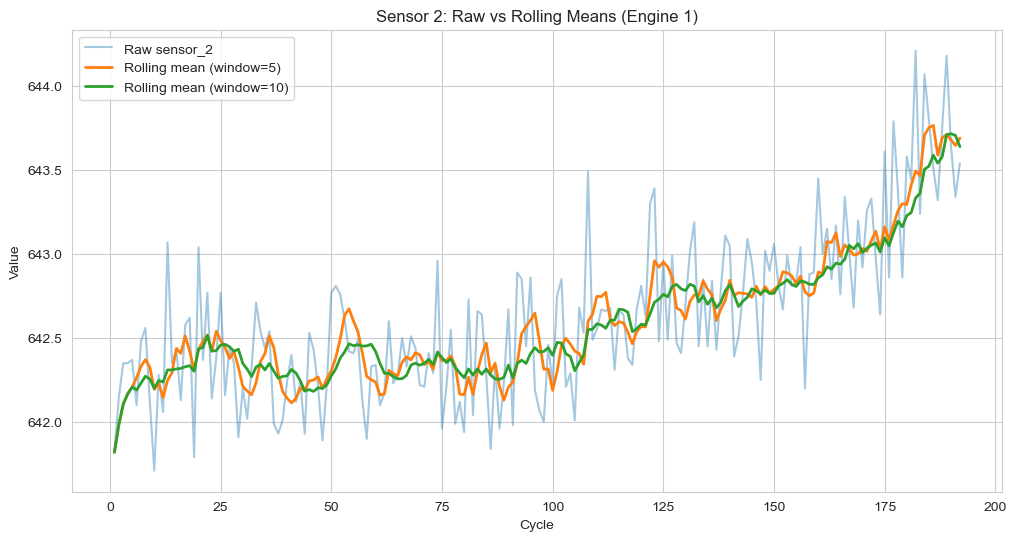

In [27]:
# Pick the first engine and visualize raw vs rolling means
engine_id = train_data['unit_number'].unique()[0]
engine_data = train_data[train_data['unit_number'] == engine_id]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(engine_data['time_cycles'], engine_data['sensor_2'], 
        label='Raw sensor_2', alpha=0.4)
ax.plot(engine_data['time_cycles'], engine_data['sensor_2_roll_mean_5'], 
        label='Rolling mean (window=5)', linewidth=2)
ax.plot(engine_data['time_cycles'], engine_data['sensor_2_roll_mean_10'], 
        label='Rolling mean (window=10)', linewidth=2)
ax.set_title(f'Sensor 2: Raw vs Rolling Means (Engine {engine_id})')
ax.set_xlabel('Cycle')
ax.set_ylabel('Value')
ax.legend()

import os
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/rolling_features_demo.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
print(f"Final train shape: {train_data.shape}")
print(f"Final val shape: {val_data.shape}")
print(f"Total NaN: {train_data.isnull().sum().sum() + val_data.isnull().sum().sum()}")
print(f"\nSample of new columns: {[c for c in train_data.columns if 'roll' in c][:5]}")

Final train shape: (16340, 79)
Final val shape: (4291, 79)
Total NaN: 0

Sample of new columns: ['sensor_2_roll_mean_5', 'sensor_2_roll_std_5', 'sensor_2_roll_mean_10', 'sensor_2_roll_std_10', 'sensor_3_roll_mean_5']


### Separate Features (X) and Target (y)

In [29]:
# Columns that are NOT features (IDs and targets)
non_feature_cols = ['unit_number', 'time_cycles', 'RUL', 'RUL_clipped']

# Everything else is a feature
feature_cols = [col for col in train_data.columns if col not in non_feature_cols]

print(f"Number of features: {len(feature_cols)}")
print(f"First 5 features: {feature_cols[:5]}")
print(f"Last 5 features: {feature_cols[-5:]}")

Number of features: 75
First 5 features: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7']
Last 5 features: ['sensor_20_roll_std_10', 'sensor_21_roll_mean_5', 'sensor_21_roll_std_5', 'sensor_21_roll_mean_10', 'sensor_21_roll_std_10']


In [30]:
# Features (X) and target (y) for training
X_train = train_data[feature_cols].copy()
y_train = train_data['RUL_clipped'].copy()

# Features (X) and target (y) for validation
X_val = val_data[feature_cols].copy()
y_val = val_data['RUL_clipped'].copy()


In [31]:
y_val.shape

(4291,)

In [32]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit ONLY on training data — this learns mean and std from train
scaler.fit(X_train)

# Transform both train and val using train's parameters
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Convert back to DataFrame (transform returns numpy array — we lose column names)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=feature_cols, index=X_val.index)

In [33]:
X_train_scaled.shape

(16340, 75)

In [34]:
# Training data should have mean ≈ 0 and std ≈ 1 for each column
print("Training data after scaling:")
print(f"  Mean of means: {X_train_scaled.mean().mean():.4f}  (should be ~0)")
print(f"  Mean of stds:  {X_train_scaled.std().mean():.4f}  (should be ~1)")

print("\nValidation data after scaling:")
print(f"  Mean of means: {X_val_scaled.mean().mean():.4f}  (close to 0 but not exact)")
print(f"  Mean of stds:  {X_val_scaled.std().mean():.4f}  (close to 1 but not exact)")

Training data after scaling:
  Mean of means: -0.0000  (should be ~0)
  Mean of stds:  1.0000  (should be ~1)

Validation data after scaling:
  Mean of means: -0.0294  (close to 0 but not exact)
  Mean of stds:  0.9956  (close to 1 but not exact)


In [39]:
import joblib

# Save scaled features
X_train_scaled.to_csv('data/processed/X_train_scaled.csv', index=False)
X_val_scaled.to_csv('data/processed/X_val_scaled.csv', index=False)

# Save targets
y_train.to_csv('data/processed/y_train.csv', index=False)
y_val.to_csv('data/processed/y_val.csv', index=False)

# Save the scaler object — we'll need this exact one for test data later
joblib.dump(scaler, 'data/processed/scaler.pkl')

# Save the feature column names too (for consistency later)
pd.Series(feature_cols).to_csv('data/processed/feature_cols.csv', index=False, header=False)

print("✓ All files saved:")
print("  - X_train_scaled.csv")
print("  - X_val_scaled.csv")
print("  - y_train.csv")
print("  - y_val.csv")
print("  - scaler.pkl")
print("  - feature_cols.csv")

✓ All files saved:
  - X_train_scaled.csv
  - X_val_scaled.csv
  - y_train.csv
  - y_val.csv
  - scaler.pkl
  - feature_cols.csv


In [42]:
import os

files_to_check = [
    'data/processed/X_train_scaled.csv',
    'data/processed/X_val_scaled.csv',
    'data/processed/y_train.csv',
    'data/processed/y_val.csv',
    'data/processed/scaler.pkl',
    'data/processed/feature_cols.csv'
]

print("File verification:")
for f in files_to_check:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f"  ✓ {f} ({size_kb:.1f} KB)")
    else:
        print(f"  ✗ MISSING: {f}")

File verification:
  ✓ data/processed/X_train_scaled.csv (23546.7 KB)
  ✓ data/processed/X_val_scaled.csv (6188.8 KB)
  ✓ data/processed/y_train.csv (71.2 KB)
  ✓ data/processed/y_val.csv (18.8 KB)
  ✓ data/processed/scaler.pkl (4.5 KB)
  ✓ data/processed/feature_cols.csv (1.5 KB)


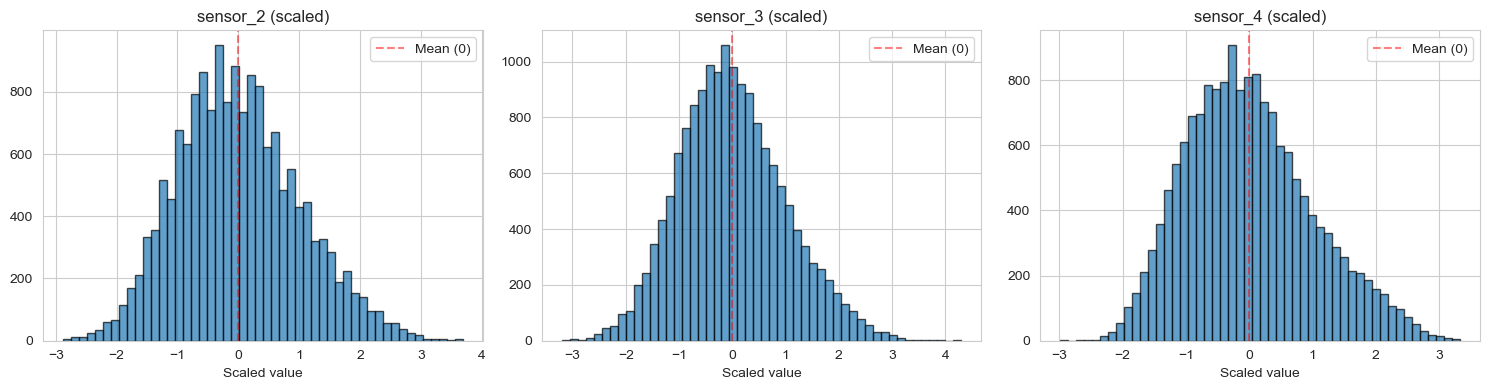

In [43]:
# Pick 3 scaled sensors and verify they look bell-curve-ish around 0
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, sensor in zip(axes, ['sensor_2', 'sensor_3', 'sensor_4']):
    ax.hist(X_train_scaled[sensor], bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', alpha=0.5, label='Mean (0)')
    ax.set_title(f'{sensor} (scaled)')
    ax.set_xlabel('Scaled value')
    ax.legend()

plt.tight_layout()
plt.savefig('plots/scaled_features_histograms.png', dpi=150)
plt.show()

In [46]:
X_train_scaled.mean().mean() 
# approximately zero

np.float64(-2.615772923075423e-13)

In [45]:
X_val_scaled.mean().mean()

np.float64(-0.02940607419325527)